In [17]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# 1. 데이터 불러오기

In [18]:
def find_input_dir():
    for c in ['/kaggle/input/competitions/rogii-wellbore-geology-prediction',
              '../data/raw']:
        if os.path.isdir(c):
            return c
    raise FileNotFoundError('데이터 경로를 찾을 수 없음')

INPUT_DIR = find_input_dir()
TRAIN_DIR = os.path.join(INPUT_DIR, 'train')
TEST_DIR  = os.path.join(INPUT_DIR, 'test')
print(f'INPUT_DIR = {INPUT_DIR}')

# 우물 ID 목록
_train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, '*__horizontal_well.csv')))
_test_files  = sorted(glob.glob(os.path.join(TEST_DIR,  '*__horizontal_well.csv')))
TRAIN_WIDS = [os.path.basename(f).split('__')[0] for f in _train_files]
TEST_WIDS  = [os.path.basename(f).split('__')[0] for f in _test_files]
print(f'Train wells: {len(TRAIN_WIDS)}, Test wells: {len(TEST_WIDS)}')

INPUT_DIR = ../data/raw
Train wells: 773, Test wells: 3


In [19]:
def load_well(wid, split='train'):
    base = TRAIN_DIR if split == 'train' else TEST_DIR
    hw = pd.read_csv(os.path.join(base, f'{wid}__horizontal_well.csv'))
    tw = pd.read_csv(os.path.join(base, f'{wid}__typewell.csv'))
    return hw, tw

# 2. 지층 경계선을 이용해 TVT를 계산하는 함수
- ref_col: 기준점으로 쓸 지층 경계선 이름

In [20]:
def tvt_from_contacts(hw_tr, tw_tr, ref_col='EGFDU'):
    tw_g = tw_tr.dropna(subset=['Geology'])
    # 같은 지층에서 경계선 값 찾기
    ref_tvt = tw_g[tw_g['Geology'] == ref_col]['TVT'].min()
    if np.isnan(ref_tvt):
        ref_col = tw_g['Geology'].iloc[0]
        ref_tvt = tw_g[tw_g['Geology'] == ref_col]['TVT'].min()
    # 실제 TVT 값과 추정 TVT 값 간 차이의 평균
    offset = (hw_tr['TVT'] - (ref_tvt - (hw_tr['Z'] - hw_tr[ref_col]))).mean()
    return ref_tvt - (hw_tr['Z'] - hw_tr[ref_col]) + offset

# 3. Particle Filter (Hidden 우물용)

GR 신호를 typewell GR과 sequential 매칭해서 TVT 추정.

| 파라미터 | 값 | 의미 |
|---|---|---|
| MOM | 0.998 | momentum (높을수록 부드러움) |
| VN | 0.002 | velocity noise |
| PN | 0.005 | position noise |
| gs clip | [10, 60] | likelihood 폭 |

In [21]:
def run_particle_filter(hw, tw, n_particles=2000, seed=42):
    """
    GR 매칭 기반 Particle Filter (baseline 파라미터).
    """
    tw_s = tw.sort_values('TVT')
    tw_tvt = tw_s['TVT'].values.astype(float)
    tw_gr  = tw_s['GR'].fillna(tw_s['GR'].mean()).values.astype(float)

    kn = hw[hw['TVT_input'].notna()]
    ev = hw[hw['TVT_input'].isna()]
    if len(ev) == 0:
        return hw['TVT_input'].values.astype(float).copy(), 0.0

    last_tvt = float(kn.iloc[-1]['TVT_input'])
    last_Z   = float(kn.iloc[-1]['Z'])
    last_MD  = float(kn.iloc[-1]['MD'])

    # GR 잡음 계산 (known 구간의 GR 잔차 std)
    tw_at_k = np.interp(kn['TVT_input'].values, tw_tvt, tw_gr)
    gs = float(np.clip(np.nanstd(kn['GR'].fillna(0).values - tw_at_k), 10., 60.))

    # 최근 30개 지점에서 진행률(rate) 계산: 깊이 변화 속도
    tail = kn.tail(30)
    dt = np.diff(tail['TVT_input'].values)
    dz = np.diff(tail['Z'].values)
    dm = np.diff(tail['MD'].values)
    m  = dm > 0
    ir = float(np.median((dt + dz)[m] / dm[m])) if m.sum() >= 3 else 0.0

    # === Motion / observation 파라미터 (baseline) ===
    MOM    = 0.998   # momentum
    VN     = 0.002   # velocity noise
    PN     = 0.005   # position noise
    RP     = 0.1     # resample 후 position perturbation
    RR     = 0.001   # resample 후 rate perturbation
    RESAMP = 0.5     # n_eff < RESAMP*N 일 때 resample

    # 가상의 드릴 N개 초기화
    N = n_particles
    rng = np.random.default_rng(seed)
    ls  = last_tvt + last_Z
    pos  = ls + 2.0 * rng.standard_normal(N)
    rate = ir + 0.01 * rng.standard_normal(N)
    w    = np.ones(N) / N

    md_v = ev['MD'].values.astype(float)
    z_v  = ev['Z'].values.astype(float)
    gr_interp = hw['GR'].interpolate(limit_direction='both').fillna(tw_gr.mean())
    gr_v = gr_interp.values.astype(float)[ev.index]

    out_vals = hw['TVT_input'].values.astype(float).copy()
    res = np.empty(len(ev))
    prev_MD = last_MD
    log_lik = 0.0

    for i in range(len(ev)):
        dm_step = max(md_v[i] - prev_MD, 1.0)
        rate = MOM * rate + VN * rng.standard_normal(N)
        pos  = pos + rate * dm_step + PN * rng.standard_normal(N)
        tvt_p = pos - z_v[i]
        tvt_p = np.clip(tvt_p, tw_tvt[0] - 100, tw_tvt[-1] + 100)
        pos   = tvt_p + z_v[i]

        # Likelihood: GR mismatch에 Gaussian
        eg = np.interp(tvt_p, tw_tvt, tw_gr)
        d  = (gr_v[i] - eg) / gs
        lk = np.maximum(np.exp(-0.5 * np.minimum(d**2, 600.)), 1e-300)

        avg_lk = float((w * lk).sum())
        log_lik += np.log(max(avg_lk, 1e-300))
        w *= lk
        ws = w.sum()
        w = w / ws if ws > 0 else np.ones(N) / N

        # Resampling
        if 1.0 / (w**2).sum() < RESAMP * N:
            cum = np.cumsum(w)
            u0  = rng.uniform(0, 1.0 / N)
            idx = np.clip(np.searchsorted(cum, u0 + np.arange(N) / N), 0, N - 1)
            pos  = pos[idx]  + RP * rng.standard_normal(N)
            rate = rate[idx] + RR * rng.standard_normal(N)
            w    = np.ones(N) / N

        res[i] = float(np.dot(w, pos - z_v[i]))
        prev_MD = md_v[i]

    out_vals[list(ev.index)] = res
    return out_vals, log_lik

In [22]:
def run_pf_lik_ensemble(hw, tw, n_particles=500, n_seeds=16, scale=5.0,
                        return_internals=False):
    """
    여러 seed로 PF 돌리고 log-likelihood 가중평균.
    """
    preds, liks = [], []
    for s in range(n_seeds):
        p, ll = run_particle_filter(hw, tw, n_particles=n_particles, seed=s)
        preds.append(p)
        liks.append(ll)

    liks = np.array(liks)
    weights = np.exp((liks - liks.max()) / scale)
    weights /= weights.sum()
    ensemble_pred = (weights[:, None] * np.stack(preds, 0)).sum()
    if return_internals:
        return ensemble_pred, liks, weights
    return ensemble_pred

## log likelihood 시각화 (scale=5)
- n_eff ≈ PROBE_N_SEEDS → scale이 너무 커서 균등 가중치 (scale 줄이기)
- n_eff ≈ 1 → winner-takes-all (scale 키우기)
- n_eff ≈ 4090 (3070%) → 적절

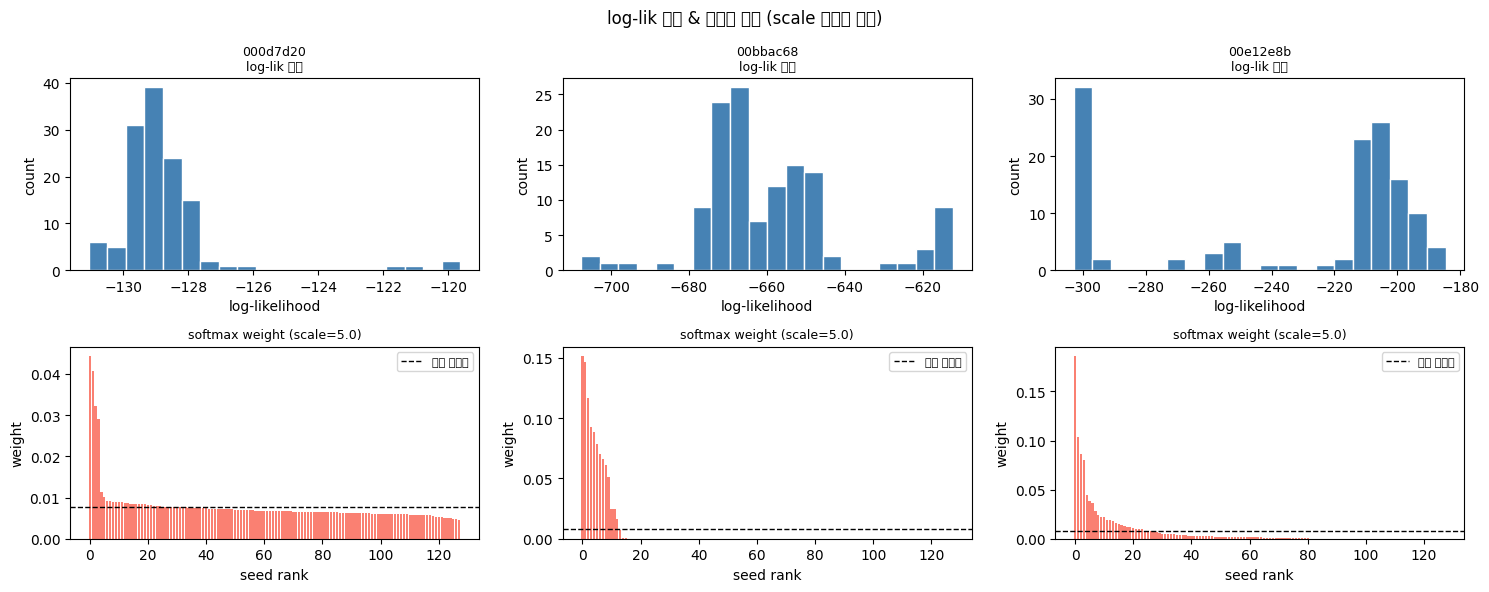


=== scale 진단 ===
000d7d20  log-lik 범위=11.4  n_eff=86.7/128
00bbac68  log-lik 범위=95.4  n_eff=10.2/128
00e12e8b  log-lik 범위=118.1  n_eff=14.3/128


In [23]:
PROBE_WIDS    = TRAIN_WIDS[:3]
PROBE_N_SEEDS = 128
PROBE_SCALE   = 5.0

fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for col, wid in enumerate(PROBE_WIDS):
    hw, tw = load_well(wid, 'train')
    _, liks, weights = run_pf_lik_ensemble(
        hw, tw, n_particles=500, n_seeds=PROBE_N_SEEDS,
        scale=PROBE_SCALE, return_internals=True
    )

    # 위쪽 행: log-likelihood 히스토그램
    ax_lik = axes[0, col]
    ax_lik.hist(liks, bins=20, color='steelblue', edgecolor='white')
    ax_lik.set_title(f'{wid}\nlog-lik 분포', fontsize=9)
    ax_lik.set_xlabel('log-likelihood')
    ax_lik.set_ylabel('count')

    # 아래쪽 행: softmax 가중치 분포 (내림차순)
    ax_w = axes[1, col]
    ax_w.bar(range(len(weights)), np.sort(weights)[::-1], color='salmon')
    ax_w.axhline(1 / PROBE_N_SEEDS, color='k', linestyle='--', linewidth=1,
                 label='균등 가중치')
    ax_w.set_title(f'softmax weight (scale={PROBE_SCALE})', fontsize=9)
    ax_w.set_xlabel('seed rank')
    ax_w.set_ylabel('weight')
    ax_w.legend(fontsize=8)

plt.suptitle('log-lik 분포 & 가중치 분포 (scale 적절성 확인)', fontsize=12)
plt.tight_layout()
plt.show()

# n_eff (seed 수) 로 scale 진단
print('\n=== scale 진단 ===')
for wid in PROBE_WIDS:
    hw, tw = load_well(wid, 'train')
    _, liks, weights = run_pf_lik_ensemble(
        hw, tw, n_particles=500, n_seeds=PROBE_N_SEEDS,
        scale=PROBE_SCALE, return_internals=True
    )
    n_eff = 1.0 / (weights ** 2).sum()
    lik_range = liks.max() - liks.min()
    print(f'{wid}  log-lik 범위={lik_range:.1f}  n_eff={n_eff:.1f}/{PROBE_N_SEEDS}')


# 4. 성능 평가 (RMSE)

각 우물의 `TVT_input`이 NaN인 행만 예측 대상. 진짜 `TVT`와 비교해서 RMSE 측정.

In [15]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def evaluate_well(wid, pf_n_seeds=16):
    """
    한 우물에서 contacts / PF 각각 예측 → 진짜 TVT와 비교.
    Returns: dict {wid, n_predict, contacts_rmse, pf_rmse, contacts_time, pf_time}
    """
    hw, tw = load_well(wid, 'train')
    mask = hw['TVT_input'].isna().values
    y_true = hw['TVT'].values[mask]
    if len(y_true) == 0:
        return None

    t0 = time.time()
    pred_contacts = tvt_from_contacts(hw, tw).values
    t_contacts = time.time() - t0

    t0 = time.time()
    pred_pf = run_pf_lik_ensemble(hw, tw, n_particles=500, n_seeds=pf_n_seeds)
    t_pf = time.time() - t0

    return {
        'wid': wid,
        'n_predict': int(mask.sum()),
        'contacts_rmse': rmse(y_true, pred_contacts[mask]),
        'pf_rmse': rmse(y_true, pred_pf[mask]),
        'contacts_time': t_contacts,
        'pf_time': t_pf,
    }

In [16]:
# N개 우물에 대해 평가 실행
N_WELLS = 10

results = []
for i, wid in enumerate(TRAIN_WIDS[:N_WELLS]):
    r = evaluate_well(wid, pf_n_seeds=16)
    print(f'[{i+1:>2}/{N_WELLS}] {wid}  '
          f'contacts={r["contacts_rmse"]:.4f}  '
          f'pf={r["pf_rmse"]:6.2f}  '
          f'({r["pf_time"]:.1f}s)')
    results.append(r)

df = pd.DataFrame(results)
print('\n=== RMSE 요약 ===')
print(df[['contacts_rmse', 'pf_rmse']].describe().round(4))

[ 1/10] 000d7d20  contacts=0.0053  pf=  3.92  (2.6s)
[ 2/10] 00bbac68  contacts=0.0052  pf=  4.55  (3.9s)
[ 3/10] 00e12e8b  contacts=0.0054  pf=  6.60  (2.8s)
[ 4/10] 015fe0d2  contacts=0.0053  pf=  6.55  (2.9s)
[ 5/10] 01869cd4  contacts=0.0056  pf= 16.31  (3.9s)
[ 6/10] 01982c1d  contacts=0.0056  pf=  6.56  (2.9s)
[ 7/10] 028d7b28  contacts=0.0057  pf= 15.63  (4.4s)
[ 8/10] 02e7fe5a  contacts=0.0055  pf=  5.64  (3.9s)
[ 9/10] 0390d174  contacts=0.0054  pf=  3.65  (3.5s)
[10/10] 03a935ae  contacts=0.0055  pf=  1.09  (2.0s)

=== RMSE 요약 ===
       contacts_rmse  pf_rmse
count        10.0000  10.0000
mean          0.0054   7.0476
std           0.0002   5.0018
min           0.0052   1.0867
25%           0.0053   4.0763
50%           0.0055   6.0933
75%           0.0055   6.5896
max           0.0057  16.3081
